In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Flatten, Conv2D, MaxPooling2D, Dense
import cv2
import os 
import glob

In [4]:
# Load Dataset
img_dir = r"C:\Users\janvi\OneDrive\Desktop\car licenese plate detection\images"
data_path = os.path.join(img_dir,'*g')   
files = glob.glob(data_path)
files.sort() 
#We sort the images in alphabetical order to match them to the xml files containing the annotations of the bounding boxes


# storing in X
IMAGE_SIZE = 224
X=[]
for f1 in files:
    img = cv2.imread(f1)
    img = cv2.resize(img, (IMAGE_SIZE,IMAGE_SIZE))
    X.append(np.array(img))

In [5]:
X[0]

array([[[135, 108,  54],
        [158, 124,  45],
        [179, 146,  79],
        ...,
        [ 41,  43,  42],
        [ 43,  41,  40],
        [ 37,  36,  34]],

       [[128, 105,  53],
        [154, 120,  41],
        [149, 119,  53],
        ...,
        [ 46,  46,  45],
        [ 42,  44,  41],
        [ 35,  37,  34]],

       [[127, 108,  63],
        [153, 121,  43],
        [153, 126,  63],
        ...,
        [ 44,  41,  41],
        [ 47,  49,  45],
        [ 36,  38,  34]],

       ...,

       [[ 40,  48,  71],
        [ 41,  49,  72],
        [ 42,  50,  73],
        ...,
        [ 43,  62,  99],
        [ 46,  67, 101],
        [ 47,  67, 102]],

       [[ 44,  52,  75],
        [ 43,  51,  74],
        [ 41,  49,  72],
        ...,
        [ 42,  62,  99],
        [ 47,  66, 103],
        [ 48,  67, 104]],

       [[ 44,  52,  75],
        [ 41,  50,  73],
        [ 39,  47,  70],
        ...,
        [ 45,  64, 102],
        [ 45,  64, 102],
        [ 46,  65, 103]]

In [6]:
np.array(X).shape

(433, 224, 224, 3)

In [10]:
from lxml import etree

def resizeannotation(f):
    tree = etree.parse(f)
    for dim in tree.xpath("size"):
        width = int(dim.xpath("width")[0].text)
        height = int(dim.xpath("height")[0].text)
    for dim in tree.xpath("object/bndbox"):
        xmin = int(dim.xpath("xmin")[0].text)/(width/IMAGE_SIZE)
        ymin = int(dim.xpath("ymin")[0].text)/(height/IMAGE_SIZE)
        xmax = int(dim.xpath("xmax")[0].text)/(width/IMAGE_SIZE)
        ymax = int(dim.xpath("ymax")[0].text)/(height/IMAGE_SIZE)
    return [int(xmin), int(ymin), int(xmax), int(ymax)]


ann_path = r"C:\Users\janvi\OneDrive\Desktop\car licenese plate detection\annotations"
text_files = [os.path.join(ann_path, f) for f in sorted(os.listdir(ann_path))]

print("Total annotations:", len(text_files))
print(text_files[:3])

y = []
for file in text_files:
    y.append(resizeannotation(file))

print("Bounding boxes loaded:", len(y))

Total annotations: 433
['C:\\Users\\janvi\\OneDrive\\Desktop\\car licenese plate detection\\annotations\\Cars0.xml', 'C:\\Users\\janvi\\OneDrive\\Desktop\\car licenese plate detection\\annotations\\Cars1.xml', 'C:\\Users\\janvi\\OneDrive\\Desktop\\car licenese plate detection\\annotations\\Cars10.xml']
Bounding boxes loaded: 433


In [11]:
len(y)

433

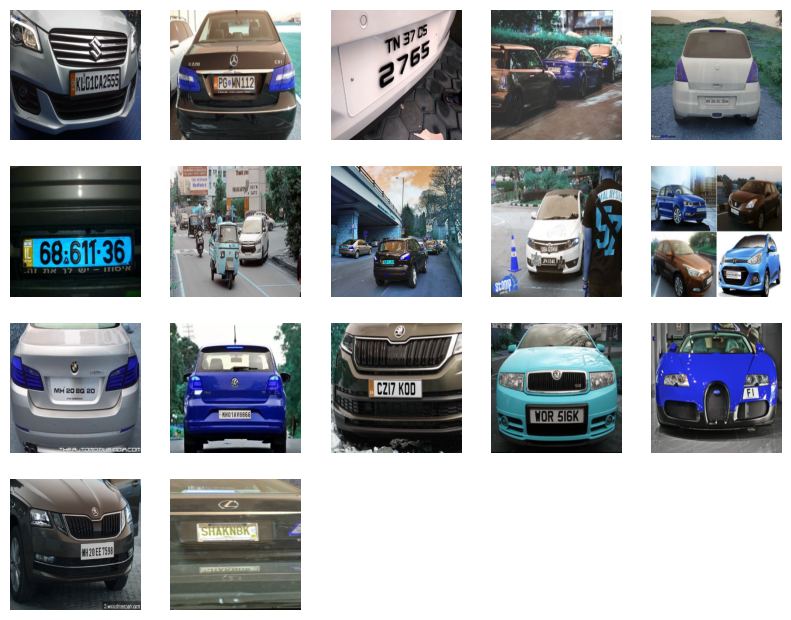

In [12]:
plt.figure(figsize=(10,20))
for i in range(0,17):
    plt.subplot(10,5, i+1)
    plt.axis("off")
    plt.imshow(X[i])

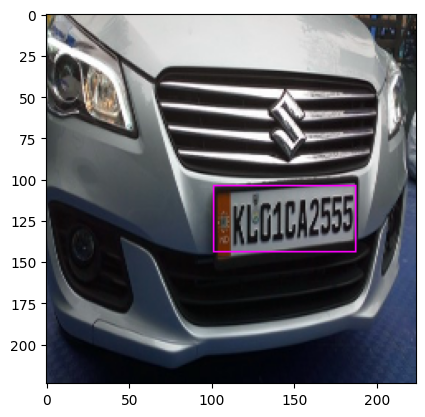

In [13]:
#Example with the first image of the dataset
image = cv2.rectangle(X[0],(y[0][0],y[0][1]),(y[0][2],y[0][3]),(255, 0, 255))
plt.imshow(image)
plt.show()

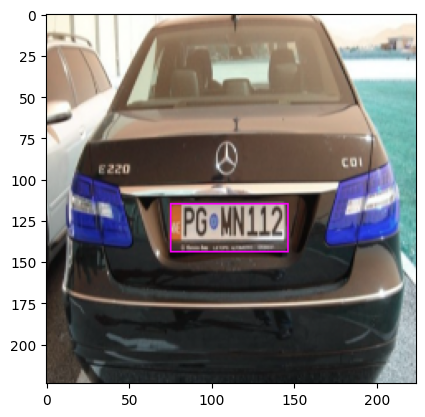

In [14]:
#Example with the second image of the dataset
image = cv2.rectangle(X[1],(y[1][0],y[1][1]),(y[1][2],y[1][3]),(255, 0, 255))
plt.imshow(image)
plt.show()

In [15]:
# Data Preprocessing and Train Test Split
X = np.array(X)
y = np.array(y)
X[0]

array([[[135, 108,  54],
        [158, 124,  45],
        [179, 146,  79],
        ...,
        [ 41,  43,  42],
        [ 43,  41,  40],
        [ 37,  36,  34]],

       [[128, 105,  53],
        [154, 120,  41],
        [149, 119,  53],
        ...,
        [ 46,  46,  45],
        [ 42,  44,  41],
        [ 35,  37,  34]],

       [[127, 108,  63],
        [153, 121,  43],
        [153, 126,  63],
        ...,
        [ 44,  41,  41],
        [ 47,  49,  45],
        [ 36,  38,  34]],

       ...,

       [[ 40,  48,  71],
        [ 41,  49,  72],
        [ 42,  50,  73],
        ...,
        [ 43,  62,  99],
        [ 46,  67, 101],
        [ 47,  67, 102]],

       [[ 44,  52,  75],
        [ 43,  51,  74],
        [ 41,  49,  72],
        ...,
        [ 42,  62,  99],
        [ 47,  66, 103],
        [ 48,  67, 104]],

       [[ 44,  52,  75],
        [ 41,  50,  73],
        [ 39,  47,  70],
        ...,
        [ 45,  64, 102],
        [ 45,  64, 102],
        [ 46,  65, 103]]

In [16]:
X = X / 255
y = y / 255
X[0]

array([[[0.52941176, 0.42352941, 0.21176471],
        [0.61960784, 0.48627451, 0.17647059],
        [0.70196078, 0.57254902, 0.30980392],
        ...,
        [0.16078431, 0.16862745, 0.16470588],
        [0.16862745, 0.16078431, 0.15686275],
        [0.14509804, 0.14117647, 0.13333333]],

       [[0.50196078, 0.41176471, 0.20784314],
        [0.60392157, 0.47058824, 0.16078431],
        [0.58431373, 0.46666667, 0.20784314],
        ...,
        [0.18039216, 0.18039216, 0.17647059],
        [0.16470588, 0.17254902, 0.16078431],
        [0.1372549 , 0.14509804, 0.13333333]],

       [[0.49803922, 0.42352941, 0.24705882],
        [0.6       , 0.4745098 , 0.16862745],
        [0.6       , 0.49411765, 0.24705882],
        ...,
        [0.17254902, 0.16078431, 0.16078431],
        [0.18431373, 0.19215686, 0.17647059],
        [0.14117647, 0.14901961, 0.13333333]],

       ...,

       [[0.15686275, 0.18823529, 0.27843137],
        [0.16078431, 0.19215686, 0.28235294],
        [0.16470588, 0

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train, test_size=0.1, random_state=42)

In [19]:
# Using CNN With Keras
model = Sequential()
# feature extactor
# 1st covolutional layer
model.add(Conv2D(64, (3,3), input_shape=(224,224,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.1))

# 2st covolutional layer
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.1))


# classification (fully connected layers)
model.add(Flatten()) 
model.add(Dense(64, activation='relu'))
model.add(Dense(4, activation='sigmoid'))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['accuracy'])
train = model.fit(X_train,y_train, validation_data=(X_val,y_val), epochs=50, batch_size=32, verbose=1)

c:\Users\janvi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5305 - loss: 0.1095 - val_accuracy: 0.6571 - val_loss: 0.0242
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5338 - loss: 0.0300 - val_accuracy: 0.6571 - val_loss: 0.0219
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5338 - loss: 0.0249 - val_accuracy: 0.7143 - val_loss: 0.0179
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6013 - loss: 0.0207 - val_accuracy: 0.6857 - val_loss: 0.0159
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6656 - loss: 0.0184 - val_accuracy: 0.5143 - val_loss: 0.0180
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.6624 - loss: 0.0145 - val_accuracy: 0.6857 - val_loss: 0.0127
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8039 - loss: 0.0099 - val_accuracy: 0.7429 - val_loss: 0.0119
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8360 - loss: 0.0068 - val_accuracy: 0.8000 - val_loss:

In [20]:
#CNN Evaluation # Test
scores = model.evaluate(X_test, y_test, verbose=0)
print("Score : %.2f%%" % (scores[1]*100))

Score : 71.26%


In [21]:
# VGG16
from tensorflow.keras.applications import VGG16
from keras.callbacks import EarlyStopping

# Create the model
model = Sequential()
# feature extraction
model.add(VGG16(weights="imagenet", include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))

# classification
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dense(128, activation="relu"))
model.add(Dense(64, activation="relu"))
model.add(Dense(4, activation="sigmoid"))

# Freeze VGG16 base layers
model.layers[0].trainable = False

# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['accuracy'])

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Train the model
train = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                  epochs=50, batch_size=32, verbose=1, callbacks=[early_stopping])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 64s 6s/step - accuracy: 0.4630 - loss: 0.0739 - val_accuracy: 0.5429 - val_loss: 0.0242
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 54s 5s/step - accuracy: 0.6334 - loss: 0.0194 - val_accuracy: 0.4000 - val_loss: 0.0126
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 55s 6s/step - accuracy: 0.7203 - loss: 0.0105 - val_accuracy: 0.8286 - val_loss: 0.0098
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 77s 8s/step - accuracy: 0.8392 - loss: 0.0054 - val_accuracy: 0.9143 - val_loss: 0.0061
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 90s 8s/step - accuracy: 0.8617 - loss: 0.0034 - val_accuracy: 0.9143 - val_loss: 0.0044
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 52s 5s/step - accuracy: 0.8457 - loss: 0.0023 - val_accuracy: 0.8571 - val_loss: 0.0049
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 57s 6s/step - accuracy: 0.8746 - loss: 0.0016 - val_accuracy: 0.8857 - val_loss: 0.0048
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1342s 149s/step - accuracy: 0

In [22]:
# Test
scores = model.evaluate(X_test, y_test, verbose=0)
print("Score : %.2f%%" % (scores[1]*100))

Score : 79.31%


In [23]:
# Save Model¶
model.save("car_plate_detector.h5")
print("Model saved successfully!")

Model saved successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 877ms/step


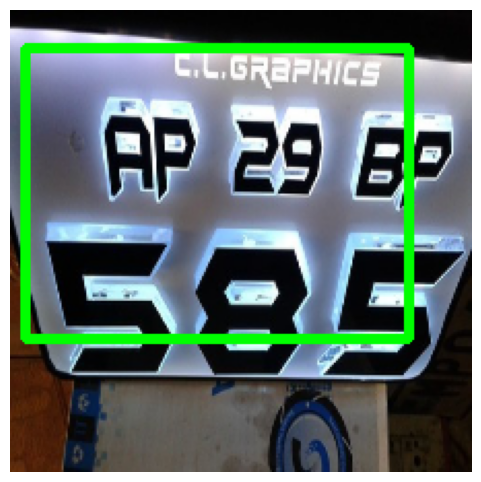

In [43]:
# No Plate Detection System
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model("car_plate_detector.h5")

def detect_car_plate(image_path):
    # Load and preprocess the image
    img = cv2.imread(image_path)
    img_resized = cv2.resize(img, (224, 224))  # Resize to match model input
    img_normalized = img_resized / 255.0       # Normalize

    # Expand dimensions to match model input shape (1, 224, 224, 3)
    img_input = np.expand_dims(img_normalized, axis=0)

    # Predict bounding box
    pred = model.predict(img_input)[0]  # Get first (and only) prediction
    xmin, ymin, xmax, ymax = pred * 224  # Scale coordinates back

    # Draw rectangle on original image
    img_with_box = img_resized.copy()
    cv2.rectangle(img_with_box, 
                    (int(xmin), int(ymin)), 
                  (int(xmax), int(ymax)), 
                  (0, 255, 0), 3)

    # Display the result
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img_with_box, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

test_image = r"C:\Users\janvi\OneDrive\Desktop\car licenese plate detection\images\Cars114.png"  # Replace with actual image path
detect_car_plate(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step


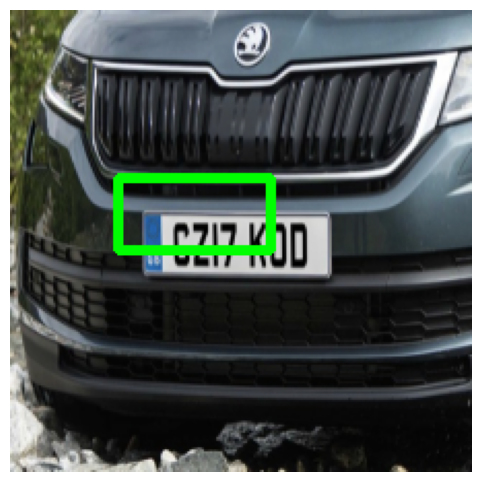

In [44]:
test_image = r"C:\Users\janvi\OneDrive\Desktop\car licenese plate detection\images\Cars109.png"  # Replace with actual image path
detect_car_plate(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step


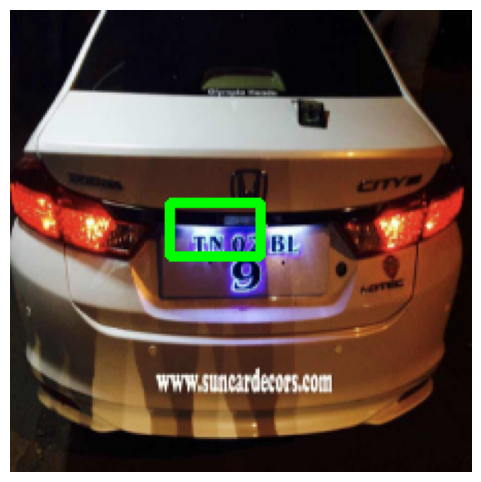

In [45]:
test_image = r"C:\Users\janvi\OneDrive\Desktop\car licenese plate detection\images\Cars138.png"  # Replace with actual image path
detect_car_plate(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step


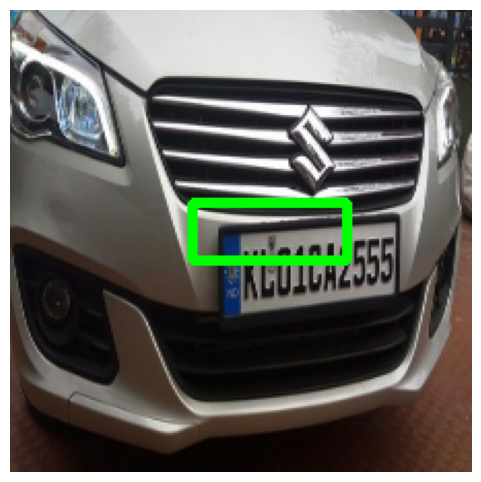

In [46]:
test_image = r"C:\Users\janvi\OneDrive\Desktop\car licenese plate detection\images\Cars147.png"  # Replace with actual image path
detect_car_plate(test_image)